# Exploratory Data Analysis

Tag frequency and distribution (real MagnaTagATune data) and
valence/arousal spread (real DEAM data, loaded separately since
MTAT has no emotion labels).

In [2]:
import sys, json
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_manifest, load_tag_vocab

train = load_manifest('train', '../data/splits')
tags = load_tag_vocab('../data/processed/toy')
print(f'{len(train)} training tracks, {len(tags)} tags')


1500 training tracks, 50 tags


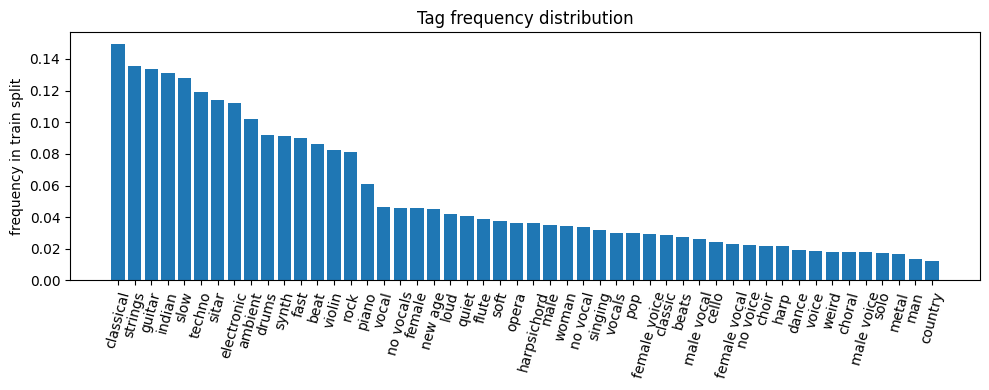

In [3]:
tag_matrix = np.array([t['tags'] for t in train])
freqs = tag_matrix.mean(axis=0)
order = np.argsort(freqs)[::-1]
plt.figure(figsize=(10,4))
plt.bar(range(len(tags)), freqs[order])
plt.xticks(range(len(tags)), [tags[i] for i in order], rotation=75)
plt.ylabel('frequency in train split')
plt.title('Tag frequency distribution')
plt.tight_layout()
plt.show()


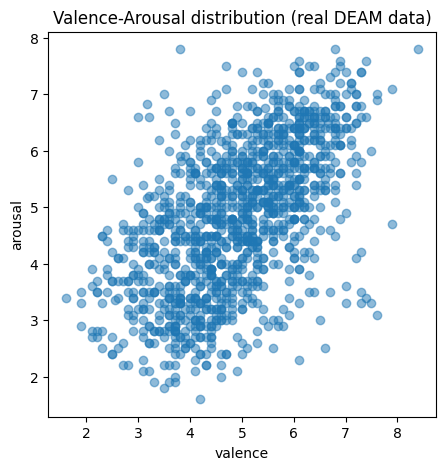

In [4]:
deam_train = load_manifest('train', '../data/splits/deam')
valence = [t['valence'] for t in deam_train]
arousal = [t['arousal'] for t in deam_train]
plt.figure(figsize=(5,5))
plt.scatter(valence, arousal, alpha=0.5)
plt.xlabel('valence'); plt.ylabel('arousal')
plt.title('Valence-Arousal distribution (real DEAM data)')
plt.show()